# 04 - Analysis and Comparison

Deep analysis comparing KAN-based NNUE variants against the standard baseline.

**Metrics analyzed**:
- Loss convergence and final quality
- Winner prediction accuracy
- Parameter efficiency (accuracy per parameter)
- Training time comparison
- Eval error distribution across material imbalance levels
- Learned activation visualization (KAN splines)

---

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
if not os.path.exists('/content/kanue'):
    !git clone --depth 1 https://github.com/y0sif/kanue.git /content/kanue
else:
    !cd /content/kanue && git pull -q
sys.path.insert(0, '/content/kanue/src')
!pip install -q python-chess tqdm

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from kanue.models.baseline import NnBoard768
from kanue.models.kan import KanBoard768, HybridKanBoard768
from kanue.data import BulletformatBatchDataset
from kanue.utils import DriveCheckpointer, evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RESULTS_DIR = Path('/content/drive/MyDrive/kanue/results')

## 1. Load Test Data and All Models

In [3]:
DATA_DIR = Path('/content/drive/MyDrive/kanue/data')

test_loader = BulletformatBatchDataset(
    DATA_DIR / 'test.data', batch_size=16384, shuffle=False
)

print(f'Test set: {len(test_loader.data):,} positions')

Test set: 1,000,000 positions


In [4]:
HIDDEN_SIZE = 128
GRID_SIZE = 5

models = {}

# Load baseline
baseline = NnBoard768(HIDDEN_SIZE).to(device)
ckpt = DriveCheckpointer('baseline')
epoch = ckpt.latest_checkpoint()
if epoch is not None:
    ckpt.load_checkpoint(epoch, baseline)
    models['Baseline NNUE'] = baseline
    print(f'Loaded baseline from epoch {epoch}')

# Load full KAN
kan = KanBoard768(HIDDEN_SIZE, GRID_SIZE).to(device)
ckpt = DriveCheckpointer(f'kan_g{GRID_SIZE}')
epoch = ckpt.latest_checkpoint()
if epoch is not None:
    ckpt.load_checkpoint(epoch, kan)
    models[f'Full KAN (grid={GRID_SIZE})'] = kan
    print(f'Loaded KAN from epoch {epoch}')

# Load hybrid
hybrid = HybridKanBoard768(HIDDEN_SIZE, GRID_SIZE).to(device)
ckpt = DriveCheckpointer(f'hybrid_kan_g{GRID_SIZE}')
epoch = ckpt.latest_checkpoint()
if epoch is not None:
    ckpt.load_checkpoint(epoch, hybrid)
    models[f'Hybrid KAN (grid={GRID_SIZE})'] = hybrid
    print(f'Loaded hybrid from epoch {epoch}')

Loaded baseline from epoch 49
Loaded KAN from epoch 49
Loaded hybrid from epoch 49


## 2. Test Set Evaluation

In [5]:
results = {}

for name, model in models.items():
    metrics = evaluate(model, test_loader, device)
    n_params = sum(p.numel() for p in model.parameters())
    results[name] = {**metrics, 'params': n_params}
    print(f'{name:<30} loss={metrics["loss"]:.6f}  acc={metrics["accuracy"]:.4f}  params={n_params:,}')

# Save results
import json
with open(RESULTS_DIR / 'test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

/content/kanue/src/kanue/data/loader.py:62: RuntimeWarning: overflow encountered in scalar negative
  sq = int(bits & np.uint64(-np.int64(bits))).bit_length() - 1


Baseline NNUE                  loss=0.015502  acc=0.7885  params=98,689
Full KAN (grid=5)              loss=0.012065  acc=0.8094  params=394,496
Hybrid KAN (grid=5)            loss=0.013262  acc=0.8029  params=100,736


## 3. Training Curve Comparison

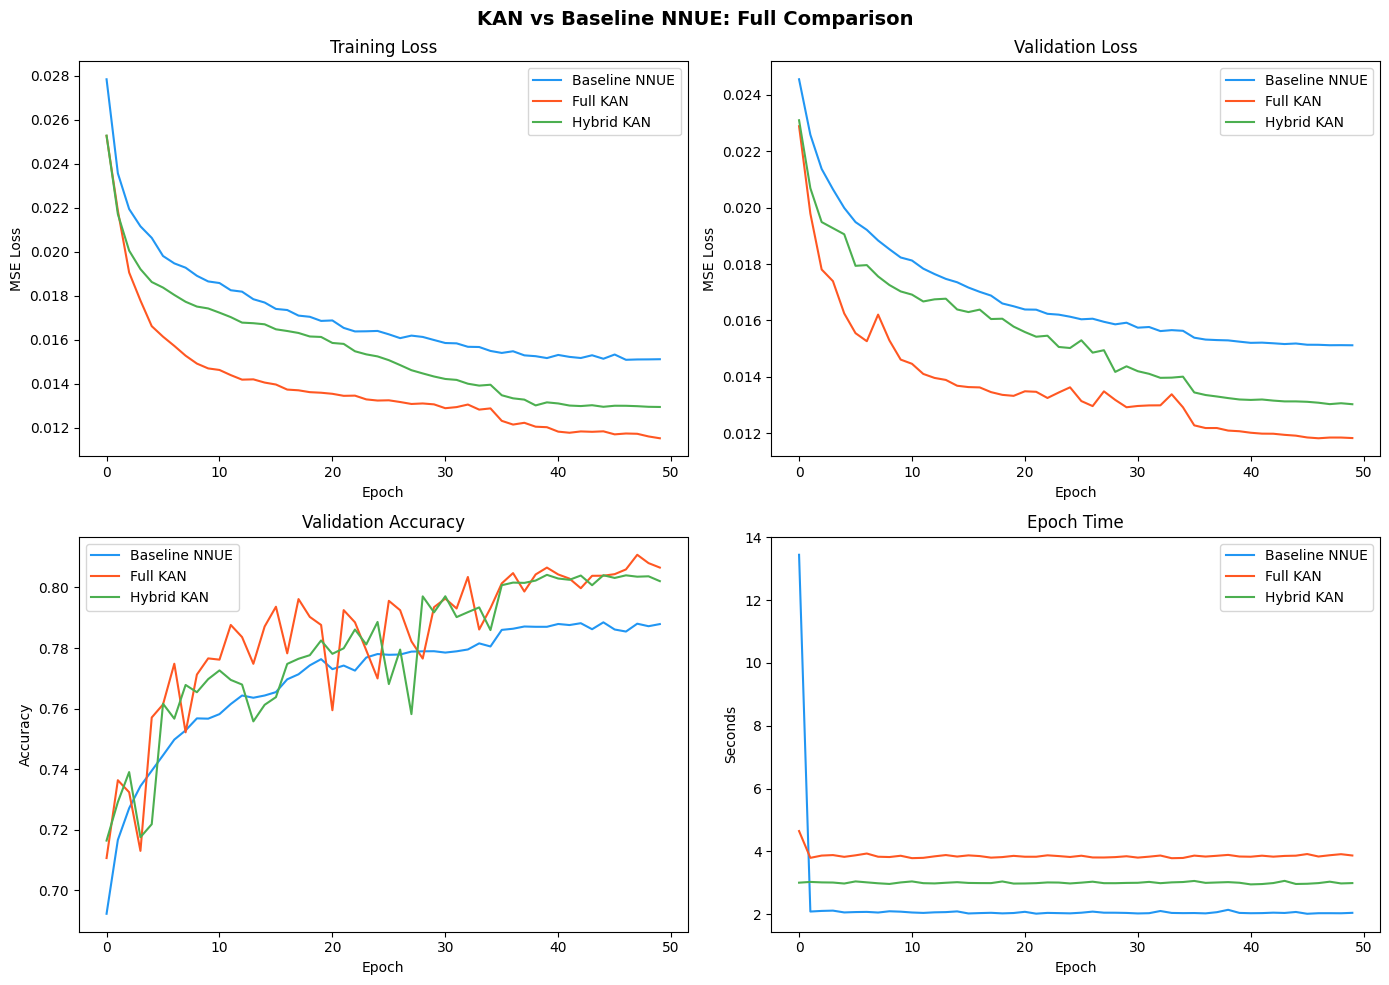

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

logs = {}
for name in ['baseline', f'kan_g{GRID_SIZE}', f'hybrid_kan_g{GRID_SIZE}']:
    ckpt = DriveCheckpointer(name)
    log = ckpt.load_log()
    if log:
        logs[name] = log

colors = {'baseline': '#2196F3', f'kan_g{GRID_SIZE}': '#FF5722', f'hybrid_kan_g{GRID_SIZE}': '#4CAF50'}
labels = {'baseline': 'Baseline NNUE', f'kan_g{GRID_SIZE}': 'Full KAN', f'hybrid_kan_g{GRID_SIZE}': 'Hybrid KAN'}

for name, log in logs.items():
    c, l = colors.get(name, 'gray'), labels.get(name, name)
    axes[0, 0].plot(log['train_loss'], color=c, label=l)
    axes[0, 1].plot(log['val_loss'], color=c, label=l)
    axes[1, 0].plot(log['val_accuracy'], color=c, label=l)
    axes[1, 1].plot(log['epoch_time'], color=c, label=l)

axes[0, 0].set_title('Training Loss'); axes[0, 0].set_ylabel('MSE Loss'); axes[0, 0].legend()
axes[0, 1].set_title('Validation Loss'); axes[0, 1].set_ylabel('MSE Loss'); axes[0, 1].legend()
axes[1, 0].set_title('Validation Accuracy'); axes[1, 0].set_ylabel('Accuracy'); axes[1, 0].legend()
axes[1, 1].set_title('Epoch Time'); axes[1, 1].set_ylabel('Seconds'); axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.suptitle('KAN vs Baseline NNUE: Full Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'full_comparison.png'), dpi=150)
plt.show()

## 4. Error Distribution Analysis

In [7]:
# Get predictions from each model on test set
all_preds = {}
all_targets = []

with torch.no_grad():
    for stm, nstm, targets in test_loader:
        all_targets.append(targets.numpy())
        stm, nstm = stm.to(device), nstm.to(device)
        for name, model in models.items():
            model.eval()
            pred = model(stm, nstm).cpu().numpy()
            all_preds.setdefault(name, []).append(pred)

all_targets = np.concatenate(all_targets).flatten()
for name in all_preds:
    all_preds[name] = np.concatenate(all_preds[name]).flatten()

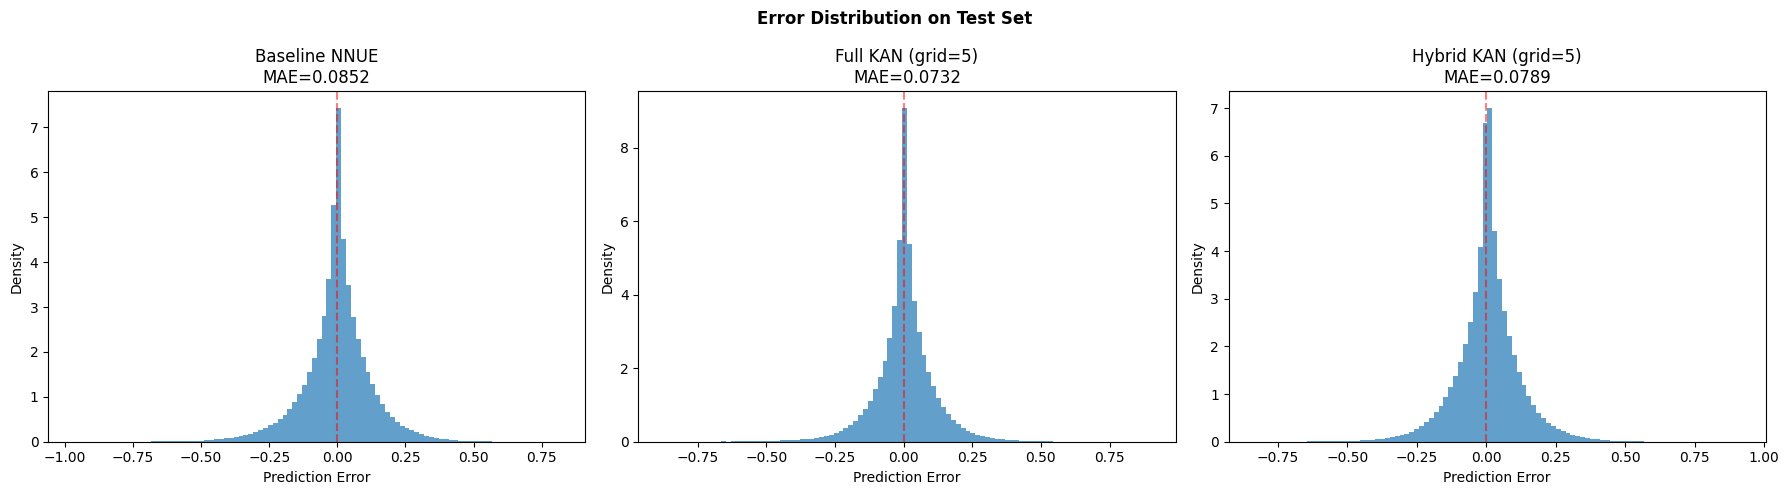

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, all_preds.items()):
    errors = preds - all_targets
    ax.hist(errors, bins=100, alpha=0.7, density=True)
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}\nMAE={np.abs(errors).mean():.4f}')
    ax.set_xlabel('Prediction Error')
    ax.set_ylabel('Density')

plt.suptitle('Error Distribution on Test Set', fontweight='bold')
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'error_distribution.png'), dpi=150)
plt.show()

## 5. Learned Activation Visualization

One of KAN's key advantages: we can visualize what activation functions were learned.
This provides interpretability that fixed CReLU/SCReLU cannot offer.

In [ ]:
def visualize_kan_activations(model, layer_name, n_edges=16):
    """Visualize learned B-spline activation functions from a KAN layer."""
    layer = dict(model.named_modules())[layer_name]
    x_range = torch.linspace(-2, 2, 200).unsqueeze(1).to(device)
    x_tiled = x_range.expand(-1, layer.in_features)

    with torch.no_grad():
        basis = layer.b_splines(x_tiled)
        spline_w = layer.spline_weight.detach()
        base_w = layer.base_weight.detach()

    n_show = min(n_edges, layer.out_features * layer.in_features)
    cols = 4
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))

    x_np = x_range.cpu().numpy().flatten()
    edge_idx = 0

    for out_j in range(min(4, layer.out_features)):
        for in_i in range(min(4, layer.in_features)):
            if edge_idx >= n_show:
                break
            ax = axes.flat[edge_idx]
            gs = layer.grid_size + layer.spline_order
            start = in_i * gs
            end = start + gs
            edge_basis = basis[:, start:end].cpu().numpy()
            edge_weights = spline_w[out_j, start:end].cpu().numpy()
            spline_out = edge_basis @ edge_weights

            silu_x = x_np / (1 + np.exp(-x_np))
            base_out = silu_x * base_w[out_j, in_i].cpu().item() * layer._scale_base

            total = spline_out + base_out
            ax.plot(x_np, total, 'b-', linewidth=1.5, label='Total')
            ax.plot(x_np, spline_out, 'r--', alpha=0.5, label='Spline')
            ax.plot(x_np, base_out, 'g--', alpha=0.5, label='Base')
            ax.set_title(f'Edge ({in_i},{out_j})', fontsize=9)
            ax.tick_params(labelsize=7)
            if edge_idx == 0:
                ax.legend(fontsize=7)
            edge_idx += 1

    for i in range(edge_idx, len(axes.flat)):
        axes.flat[i].set_visible(False)

    plt.suptitle(f'Learned Activations: {layer_name}', fontweight='bold')
    plt.tight_layout()
    return fig

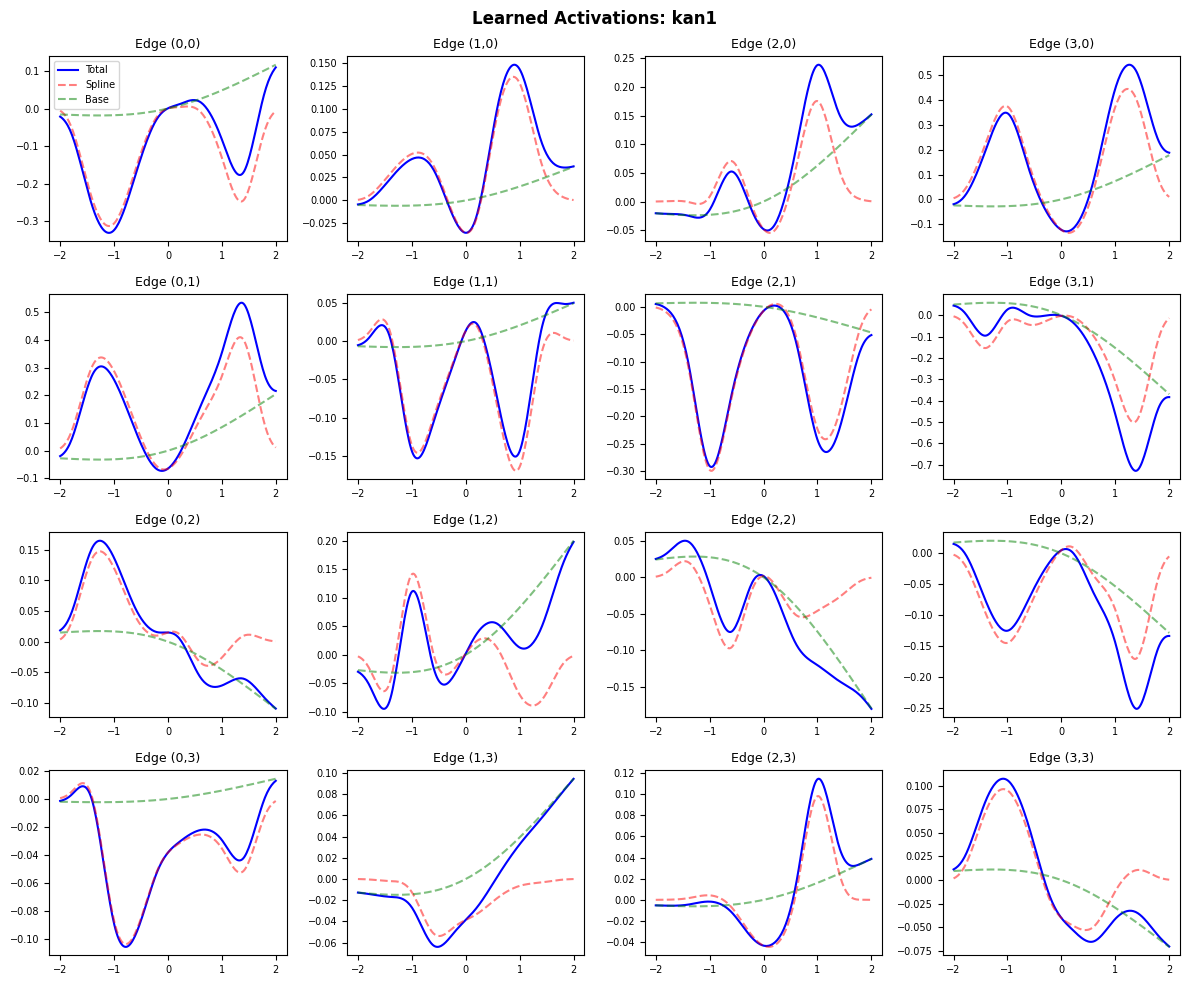

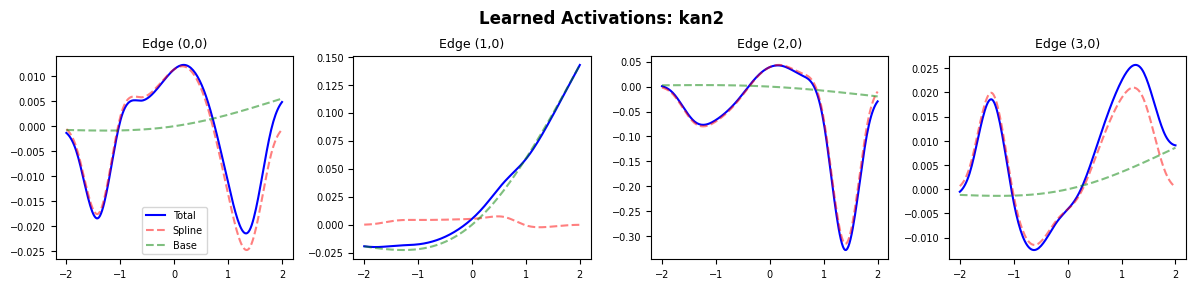

In [13]:
if f'Full KAN (grid={GRID_SIZE})' in models:
    kan_model = models[f'Full KAN (grid={GRID_SIZE})']

    fig = visualize_kan_activations(kan_model, 'kan1')
    plt.savefig(str(RESULTS_DIR / 'kan1_activations.png'), dpi=150)
    plt.show()

    fig = visualize_kan_activations(kan_model, 'kan2')
    plt.savefig(str(RESULTS_DIR / 'kan2_activations.png'), dpi=150)
    plt.show()
else:
    print('KAN model not loaded. Run notebook 03 first.')

## 6. Parameter Efficiency

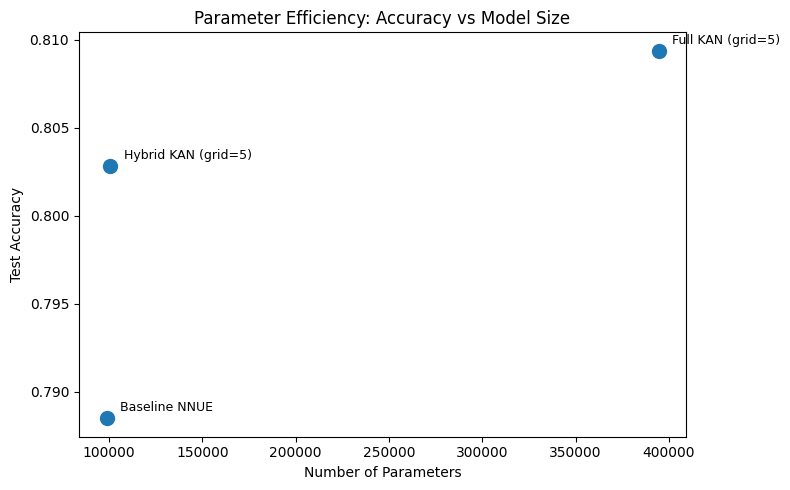

In [14]:
if results:
    fig, ax = plt.subplots(figsize=(8, 5))

    names = list(results.keys())
    params = [results[n]['params'] for n in names]
    accs = [results[n]['accuracy'] for n in names]

    ax.scatter(params, accs, s=100, zorder=5)
    for i, name in enumerate(names):
        ax.annotate(name, (params[i], accs[i]), textcoords='offset points',
                    xytext=(10, 5), fontsize=9)

    ax.set_xlabel('Number of Parameters')
    ax.set_ylabel('Test Accuracy')
    ax.set_title('Parameter Efficiency: Accuracy vs Model Size')

    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / 'param_efficiency.png'), dpi=150)
    plt.show()

## 7. Conclusions

In [15]:
print('='*60)
print('KANUE Experiment Summary')
print('='*60)
print()

if results:
    best_model = min(results.items(), key=lambda x: x[1]['loss'])
    print(f'Best model by loss: {best_model[0]}')
    print(f'  Loss: {best_model[1]["loss"]:.6f}')
    print(f'  Accuracy: {best_model[1]["accuracy"]:.4f}')
    print()

    if 'Baseline NNUE' in results:
        bl = results['Baseline NNUE']
        for name, r in results.items():
            if name == 'Baseline NNUE':
                continue
            loss_delta = (r['loss'] - bl['loss']) / bl['loss'] * 100
            acc_delta = (r['accuracy'] - bl['accuracy']) * 100
            print(f'{name} vs Baseline:')
            print(f'  Loss: {"+" if loss_delta > 0 else ""}{loss_delta:.2f}%')
            print(f'  Accuracy: {"+" if acc_delta > 0 else ""}{acc_delta:.2f} pp')
            print()

print('Next steps:')
print('- If KAN shows improvement: scale up data, try deeper architectures')
print('- If KAN matches baseline: investigate parameter efficiency gains')
print('- If KAN underperforms: try FastKAN/ReLU-KAN variants, tune grid_size')
print('- For production: implement in Bullet with LUT-KAN quantization')

KANUE Experiment Summary

Best model by loss: Full KAN (grid=5)
  Loss: 0.012065
  Accuracy: 0.8094

Full KAN (grid=5) vs Baseline:
  Loss: -22.17%
  Accuracy: +2.09 pp

Hybrid KAN (grid=5) vs Baseline:
  Loss: -14.45%
  Accuracy: +1.44 pp

Next steps:
- If KAN shows improvement: scale up data, try deeper architectures
- If KAN matches baseline: investigate parameter efficiency gains
- If KAN underperforms: try FastKAN/ReLU-KAN variants, tune grid_size
- For production: implement in Bullet with LUT-KAN quantization
